# Forecast skill

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.ticker as mticker
import proplot as pplt

fontsize = 9
pplt.rc.update({
    "figure.facecolor": "white",
    "savefig.transparent": False,
    "font.size": fontsize,
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize,
})

def repo_root():
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "configs/manuscript.yml").exists() and (p / "src/eams_seof").exists():
            return p
    raise FileNotFoundError("Repository root not found.")

ROOT = repo_root()
sys.path.insert(0, str(ROOT / "src"))

from eams_seof.config import load_config, resolve_path
from eams_seof.forecast import fixed_base_anomaly
from eams_seof.preprocessing import detrend_anomaly
from eams_seof.verification import (
    LEAD_GROUPS,
    SEASON_MONTHS,
    build_trend_adjusted_persistence_forecast,
    configuration_summary,
    evaluate_verification,
    load_masks,
    seasonal_lead_group_comparison,
)

cfg = load_config(ROOT / "configs/manuscript.yml", repo_root=ROOT)

THREE_PATH = resolve_path(ROOT, cfg["paths"]["forecast_output"])
ONE_PATH = resolve_path(ROOT, cfg["paths"]["mode1_forecast_output"])
SST_PATH = resolve_path(ROOT, cfg["paths"]["oisst_smoothed"])
MASK_PATH = resolve_path(ROOT, cfg["paths"]["region_masks"])

TRAIN = tuple(cfg["periods"]["training"])
VERIFY = tuple(cfg["periods"]["verification"])
ANOM_REF = tuple(cfg["periods"]["verification_anomaly_reference"])

if ANOM_REF != TRAIN:
    raise ValueError("Verification anomaly reference must match training period.")

v = cfg["verification"]
PRIMARY = v["primary_configuration"]
SENSITIVITY = v["sensitivity_configuration"]
ONE_MODE = v["one_mode_configuration"]
PERSISTENCE = v["persistence_configuration"]
LEADS = np.arange(1, int(cfg["forecast"]["maximum_lead_months"]) + 1)
REGIONS = ["EAMS", "YS", "ECS", "EJS"]
SEASON_ORDER = list(SEASON_MONTHS)
LEAD_GROUP_ORDER = list(LEAD_GROUPS)

FIG_DIR = ROOT / "outputs" / "png"
DATA_DIR = ROOT / "outputs" / "verification"
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.save(path, dpi=600)
    print("Saved:", path)

## Forecasts

In [2]:
sst = xr.open_dataset(SST_PATH)["sst"].sel(
    lat=slice(*cfg["domain"]["latitude"]),
    lon=slice(*cfg["domain"]["longitude"]),
)

sea_mask = np.isfinite(sst).any("time")
mask_ds = xr.open_dataset(MASK_PATH)
three_ds = xr.open_dataset(THREE_PATH)
one_ds = xr.open_dataset(ONE_PATH)

if three_ds.attrs.get("projection_method") != "weighted_gram_dual":
    raise ValueError("Rerun notebooks 04 and 05 with weighted_gram_dual projection.")

if one_ds.attrs.get("projection_method") != "weighted_gram_dual":
    raise ValueError("Rerun notebooks 04 and 05 with weighted_gram_dual projection.")

three_uncorrected, observed = fixed_base_anomaly(
    absolute_forecast_target=three_ds["sst_forecast_absolute"].sel(lead=LEADS),
    observed_sst=sst,
    anomaly_reference_period=ANOM_REF,
    sea_mask=sea_mask,
)

three_corrected, observed_check = fixed_base_anomaly(
    absolute_forecast_target=three_ds["sst_forecast_absolute_corrected"].sel(lead=LEADS),
    observed_sst=sst,
    anomaly_reference_period=ANOM_REF,
    sea_mask=sea_mask,
)

one_uncorrected, observed_one = fixed_base_anomaly(
    absolute_forecast_target=one_ds["sst_forecast_absolute"].sel(lead=LEADS),
    observed_sst=sst,
    anomaly_reference_period=ANOM_REF,
    sea_mask=sea_mask,
)

obs_a, obs_b, obs_c = xr.align(
    observed,
    observed_check,
    observed_one,
    join="exact",
)

if float(np.nanmax(np.abs((obs_a - obs_b).values))) > 1e-7:
    raise ValueError("Observed anomaly reconstruction is inconsistent.")

if float(np.nanmax(np.abs((obs_a - obs_c).values))) > 1e-7:
    raise ValueError("Observed anomaly reconstruction is inconsistent.")

(
    detrended_sst,
    training_climatology,
    trend_coefficients,
    reference_decimal_year,
) = detrend_anomaly(
    sst,
    training_period=TRAIN,
    sea_mask=sea_mask,
)

persistence_fcst, persistence_obs = build_trend_adjusted_persistence_forecast(
    detrended_sst=detrended_sst,
    forecast_template=three_corrected,
    training_climatology=training_climatology,
    trend_coefficients=trend_coefficients,
    reference_decimal_year=reference_decimal_year,
    observed_sst=sst,
    anomaly_reference_period=ANOM_REF,
    sea_mask=sea_mask,
)

obs_a, obs_p = xr.align(
    observed,
    persistence_obs,
    join="exact",
)

if float(np.nanmax(np.abs((obs_a - obs_p).values))) > 1e-7:
    raise ValueError("Persistence and model observations use different anomaly bases.")

masks = load_masks(
    mask_ds,
    observed.isel(time=0),
)

forecasts = {
    PRIMARY: three_corrected,
    SENSITIVITY: three_uncorrected,
    ONE_MODE: one_uncorrected,
    PERSISTENCE: persistence_fcst.sel(lead=LEADS),
}

## Verification

In [3]:
result = evaluate_verification(
    forecasts=forecasts,
    observed=observed,
    masks=masks,
    primary_configuration=PRIMARY,
    persistence_configuration=PERSISTENCE,
    significance_configurations=[
        PRIMARY,
        SENSITIVITY,
        PERSISTENCE,
    ],
    verification_period=VERIFY,
    min_samples=int(v["minimum_samples"]),
    n_boot=int(v["bootstrap_samples"]),
    min_boot_valid=int(v["minimum_bootstrap_valid"]),
    ci_level=float(v["ci_level"]),
    n_null=int(v["null_samples"]),
    fdr_q=float(v["fdr_q"]),
    target_month_fdr_scope=v["target_month_fdr_scope"],
    seasonal_fdr_scope=v["seasonal_fdr_scope"],
    seed=int(v["random_seed"]),
)

skill = result["skill"]
persistence_benchmark = result["persistence_benchmark"]

primary_skill = skill.sel(
    configuration=PRIMARY,
    drop=True,
)

persistence_skill = skill.sel(
    configuration=PERSISTENCE,
    drop=True,
)

skill.to_netcdf(
    resolve_path(ROOT, cfg["paths"]["skill_configurations"])
)

primary_skill.sel(
    region=["EAMS"]
).to_netcdf(
    resolve_path(ROOT, cfg["paths"]["skill_eams"])
)

primary_skill.to_netcdf(
    resolve_path(ROOT, cfg["paths"]["skill_regional"])
)

persistence_skill.sel(
    region=["EAMS"]
).to_netcdf(
    resolve_path(ROOT, cfg["paths"]["skill_persistence"])
)

persistence_benchmark.to_netcdf(
    resolve_path(ROOT, cfg["paths"]["skill_persistence_benchmark"])
)

correction_sensitivity = configuration_summary(
    skill,
    PRIMARY,
    SENSITIVITY,
)

correction_sensitivity.to_csv(
    resolve_path(ROOT, cfg["paths"]["correction_sensitivity"]),
    index=False,
)

count = three_ds["rolling_correction_archive_sample_count"]
month = three_ds["rolling_correction_target_month"]
applied = three_ds["rolling_correction_applied"]

count_df = xr.Dataset({
    "count": count,
    "month": month,
    "applied": applied,
}).to_dataframe().reset_index()

count_df = count_df[
    count_df["lead"].isin(LEADS)
]

count_df = count_df[
    count_df["init"]
    >= pd.Timestamp(cfg["rolling_correction"]["archive_start"])
]

count_df.to_csv(
    resolve_path(ROOT, cfg["paths"]["correction_archive_samples"]),
    index=False,
)

count_summary = (
    count_df
    .groupby(["month", "lead"], as_index=False)
    .agg(
        minimum_samples=("count", "min"),
        median_samples=("count", "median"),
        maximum_samples=("count", "max"),
        applied_fraction=("applied", "mean"),
    )
)

mode_skill = seasonal_lead_group_comparison(
    skill,
    first=ONE_MODE,
    second=SENSITIVITY,
    regions=["EAMS"],
).drop(columns="region")

mode_skill.to_csv(
    resolve_path(ROOT, cfg["paths"]["skill_modes"]),
    index=False,
)

regional_mode_skill = seasonal_lead_group_comparison(
    skill,
    first=ONE_MODE,
    second=SENSITIVITY,
    regions=["YS", "ECS", "EJS"],
)

regional_mode_skill.to_csv(
    resolve_path(ROOT, cfg["paths"]["skill_modes_regional"]),
    index=False,
)

display(correction_sensitivity.round(3))
display(count_summary.round(3))
display(mode_skill.round(3))

,region,metric,corrected,uncorrected,corrected_minus_uncorrected
0,EAMS,ACC,0.742,0.760,-0.018
1,EAMS,CENTERED_ACC,0.494,0.546,-0.052
2,EAMS,MSSS,0.518,0.529,-0.012
3,EAMS,RMSE,0.563,0.565,-0.002
4,EAMS,BIAS,-0.145,-0.212,0.067
5,YS,ACC,0.470,-0.328,0.798
6,YS,CENTERED_ACC,0.231,0.120,0.111
7,YS,MSSS,0.162,-0.545,0.708
8,YS,RMSE,0.791,1.095,-0.304
9,YS,BIAS,-0.260,-0.813,0.553


,month,lead,minimum_samples,median_samples,maximum_samples,applied_fraction
0,1,1,1,7.0,7,0.923
1,1,2,1,7.0,7,0.923
2,1,3,1,7.0,7,0.923
3,1,4,1,7.0,7,0.923
4,1,5,1,7.0,7,0.929
...,...,...,...,...,...,...
139,12,8,0,6.5,7,0.929
140,12,9,0,6.5,7,0.929
141,12,10,0,6.5,7,0.929
142,12,11,0,6.5,7,0.929


,season,lead_group,ACC_ONE,ACC_THREE,DACC,MSSS_ONE,MSSS_THREE,DMSSS
0,JFM,1-3,0.830,0.786,0.044,0.631,0.614,0.018
1,JFM,4-6,0.794,0.726,0.068,0.597,0.526,0.071
2,JFM,7-12,0.807,0.749,0.058,0.558,0.546,0.013
3,AMJ,1-3,0.960,0.876,0.083,0.858,0.761,0.096
4,AMJ,4-6,0.910,0.823,0.086,0.793,0.669,0.125
5,AMJ,7-12,0.873,0.828,0.045,0.688,0.641,0.047
6,JAS,1-3,0.784,0.769,0.015,0.498,0.477,0.021
7,JAS,4-6,0.705,0.746,-0.041,0.380,0.446,-0.065
8,JAS,7-12,0.879,0.865,0.014,0.556,0.572,-0.016
9,OND,1-3,0.951,0.900,0.051,0.833,0.748,0.085


Saved: /Users/jhyun/Library/CloudStorage/OneDrive-개인/jhyun91/GloSea6-SSTA-EAMS-SEOF_G1 복사본/outputs/png/Target_Month_Skill.png


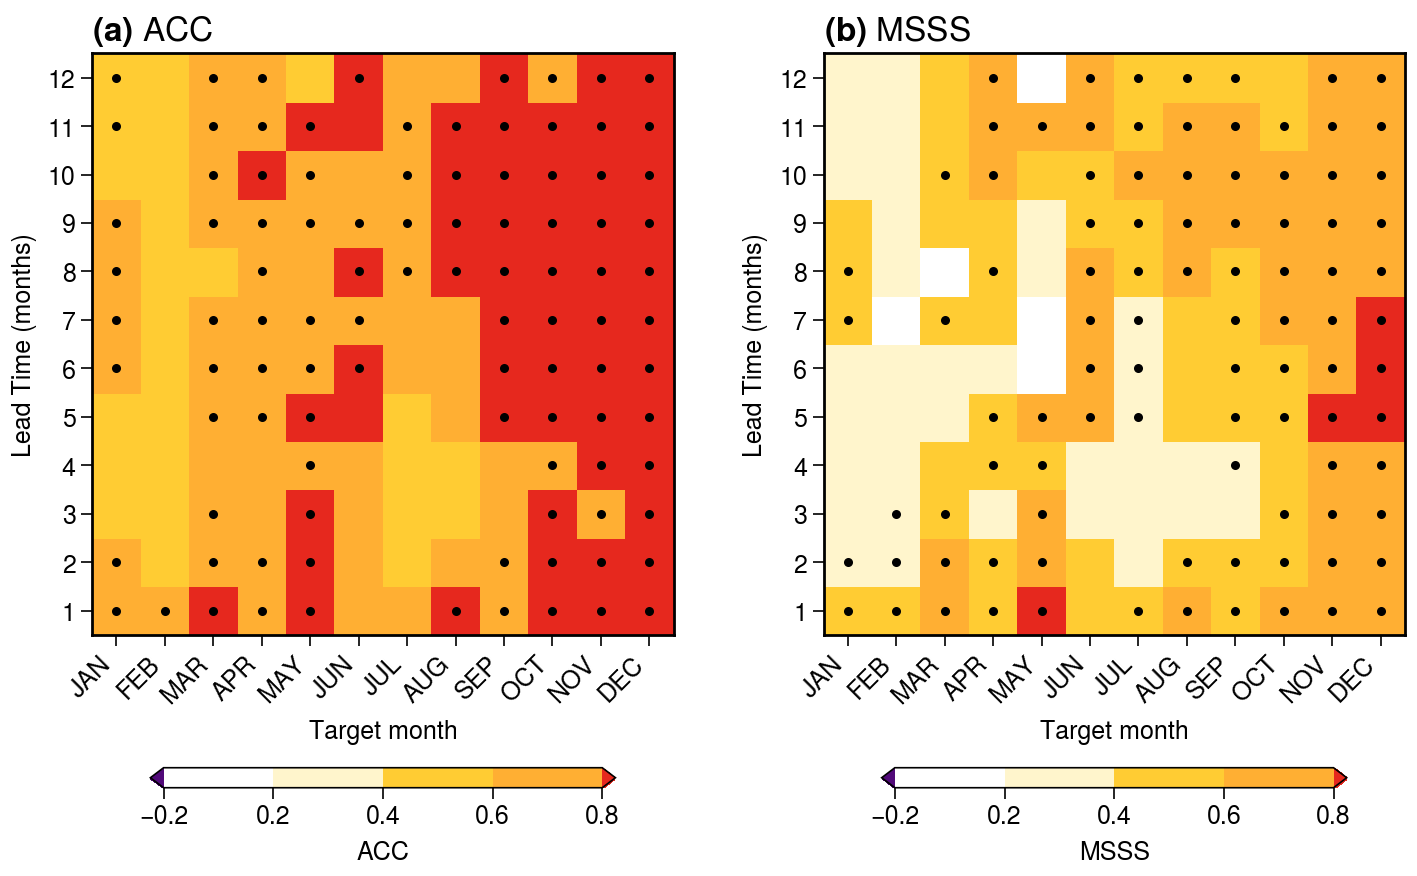

In [4]:
def skill_cmap():
    import cmaps
    base = cmaps.sunshine_diff_12lev
    colors = base(np.linspace(0, 1, 11))
    cmap = mpl.colors.ListedColormap([[1, 1, 1, 1], colors[6], colors[7], colors[8]])
    cmap.set_under(colors[0])
    cmap.set_over(colors[10])
    norm = mpl.colors.BoundaryNorm([-0.2, 0.2, 0.4, 0.6, 0.8], cmap.N)
    return cmap, norm

def plot_target(ds, name):
    if "region" in ds.dims:
        ds = ds.sel(region="EAMS", drop=True)

    leads = ds.lead.values.astype(int)
    months = ds.month.values.astype(int)
    labels = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]
    cmap, norm = skill_cmap()
    fig, axs = pplt.subplots(nrows=1, ncols=2, figwidth="18cm", share=False, wspace=6.0)

    for i, metric in enumerate(["ACC", "MSSS"]):
        values = ds[f"TARGET_{metric}"].transpose("lead", "month").values
        sig = ds[f"TARGET_SIG_{metric}"].transpose("lead", "month").values.astype(bool)
        ax = axs[i]
        mesh = ax.pcolormesh(
            np.arange(0.5, 13.5),
            np.arange(leads.min() - 0.5, leads.max() + 1.5),
            np.ma.masked_invalid(values),
            cmap=cmap,
            norm=norm,
            shading="flat",
        )
        iy, ix = np.where(sig & np.isfinite(values))
        ax.scatter(months[ix], leads[iy], s=7, c="k", zorder=5)
        ax.format(
            title=rf"$\mathbf{{({chr(97+i)})}}$ {metric}",
            titleloc="l",
            titlesize=12,
            xlim=(0.5, 12.5),
            ylim=(leads.min() - 0.5, leads.max() + 0.5),
            xticks=months.tolist(),
            xticklabels=labels,
            xrotation=45,
            yticks=leads.tolist(),
            xlabel="Target month",
            ylabel="Lead Time (months)",
            grid=False,
            ec="black",
            lw=1.0,
        )
        ax.xaxis.set_minor_locator(mticker.NullLocator())
        ax.yaxis.set_minor_locator(mticker.NullLocator())
        fig.colorbar(
            mesh,
            col=(i + 1, i + 1),
            loc="b",
            label=metric,
            length=0.80,
            width=0.10,
            extend="both",
            extendfrac=0.03,
        )

    savefig(fig, name)
    return fig, axs

fig, axs = plot_target(primary_skill, "Target_Month_Skill")

Saved: /Users/jhyun/Library/CloudStorage/OneDrive-개인/jhyun91/GloSea6-SSTA-EAMS-SEOF_G1 복사본/outputs/png/Regional_Skill.png


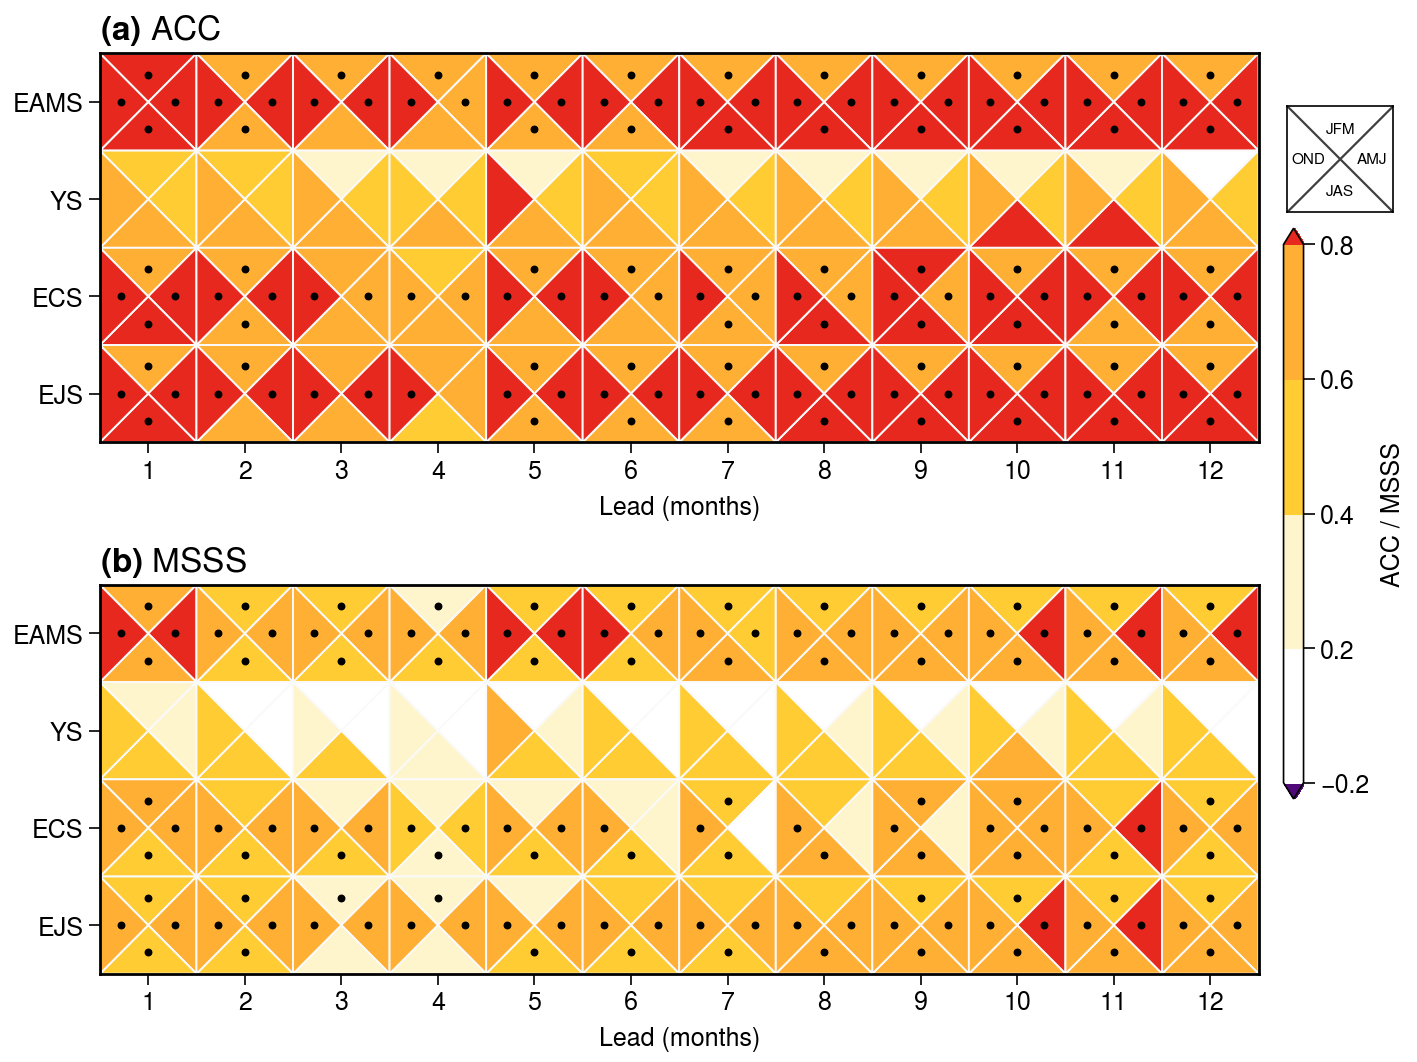

In [5]:
def plot_regions(ds, name):
    import matplotlib.patches as patches

    leads = ds.lead.values.astype(int)
    cmap, norm = skill_cmap()
    tri = {
        "JFM": lambda x, y: [(x, y + 1), (x + 1, y + 1), (x + 0.5, y + 0.5)],
        "AMJ": lambda x, y: [(x + 1, y + 1), (x + 1, y), (x + 0.5, y + 0.5)],
        "JAS": lambda x, y: [(x, y), (x + 1, y), (x + 0.5, y + 0.5)],
        "OND": lambda x, y: [(x, y + 1), (x, y), (x + 0.5, y + 0.5)],
    }
    dot = {"JFM": (0.50, 0.78), "AMJ": (0.78, 0.50), "JAS": (0.50, 0.22), "OND": (0.22, 0.50)}

    fig, axs = pplt.subplots(nrows=2, ncols=1, figwidth="18cm", figheight="13.5cm", share=False)

    for i, metric in enumerate(["ACC", "MSSS"]):
        ax = axs[i]
        values = ds[f"SEASON_{metric}"].sel(region=REGIONS)
        sig = ds[f"SEASON_SIG_{metric}"].sel(region=REGIONS)

        for ir, region in enumerate(REGIONS):
            y = len(REGIONS) - 1 - ir
            for il, lead in enumerate(leads):
                for season in SEASON_ORDER:
                    value = float(values.sel(region=region, lead=lead, season=season))
                    color = cmap(norm(value)) if np.isfinite(value) else "white"
                    ax.add_patch(patches.Polygon(tri[season](il, y), closed=True, fc=color, ec="0.98", lw=0.7))
                    if bool(sig.sel(region=region, lead=lead, season=season)) and np.isfinite(value):
                        dx, dy = dot[season]
                        ax.scatter(il + dx, y + dy, s=5, c="k", zorder=5)

        ax.format(
            title=rf"$\mathbf{{({chr(97+i)})}}$ {metric}",
            titleloc="l",
            titlesize=12,
            xlim=(0, len(leads)),
            ylim=(0, len(REGIONS)),
            xticks=(np.arange(len(leads)) + 0.5).tolist(),
            xticklabels=[str(x) for x in leads],
            yticks=(np.arange(len(REGIONS)) + 0.5).tolist(),
            yticklabels=list(reversed(REGIONS)),
            xlabel="Lead (months)",
            grid=False,
            ec="black",
            lw=1.0,
        )
        ax.xaxis.set_minor_locator(mticker.NullLocator())
        ax.yaxis.set_minor_locator(mticker.NullLocator())

    scalar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    scalar.set_array([])
    cbar = fig.colorbar(
        scalar,
        loc="r",
        rows=(1, 2),
        label="ACC / MSSS",
        length=0.62,
        width=0.10,
        extend="both",
        extendfrac=0.03,
    )

    fig.canvas.draw()
    cb = cbar.ax.get_position()
    key = fig.add_axes([cb.x0 - 0.01, cb.y1 + 0.015, 0.1, 0.1])
    key.set_xlim(0, 1)
    key.set_ylim(0, 1)
    key.set_aspect("equal")
    key.set_xticks([])
    key.set_yticks([])
    key.plot([0, 1], [0, 1], color="0.25", lw=0.8)
    key.plot([0, 1], [1, 0], color="0.25", lw=0.8)
    key.text(0.50, 0.78, "JFM", ha="center", va="center", fontsize=5.5)
    key.text(0.80, 0.50, "AMJ", ha="center", va="center", fontsize=5.5)
    key.text(0.50, 0.20, "JAS", ha="center", va="center", fontsize=5.5)
    key.text(0.20, 0.50, "OND", ha="center", va="center", fontsize=5.5)

    savefig(fig, name)
    return fig, axs

fig, axs = plot_regions(primary_skill, "Regional_Skill")

Saved: /Users/jhyun/Library/CloudStorage/OneDrive-개인/jhyun91/GloSea6-SSTA-EAMS-SEOF_G1 복사본/outputs/png/Centered_ACC_Sensitivity.png


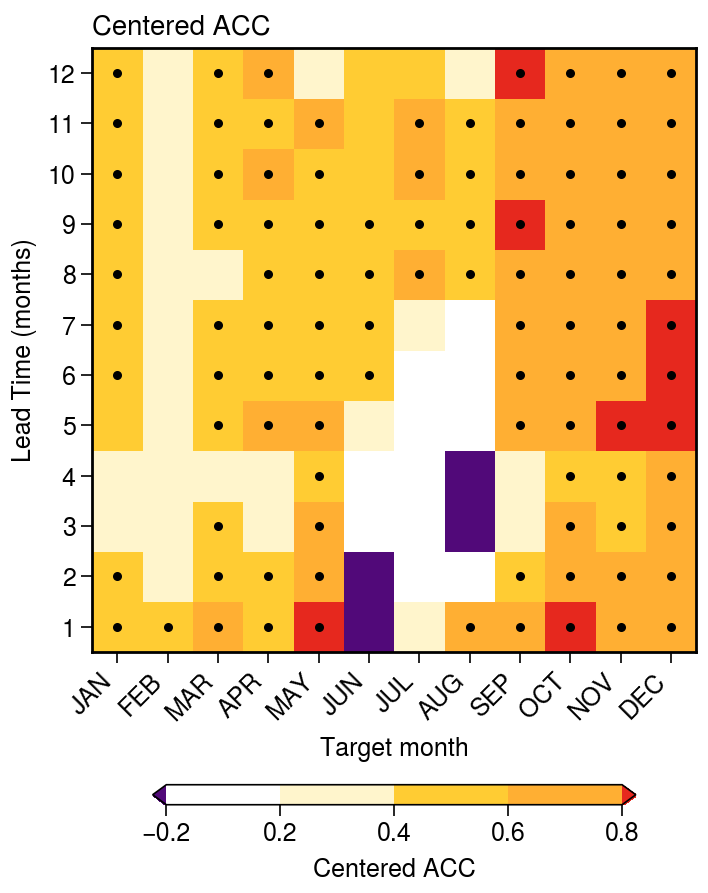

In [6]:
def plot_centered_acc(ds, name):
    ds = ds.sel(region="EAMS", drop=True)
    leads = ds.lead.values.astype(int)
    months = ds.month.values.astype(int)
    labels = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]
    cmap, norm = skill_cmap()
    values = ds["TARGET_CENTERED_ACC"].transpose("lead", "month").values
    sig = ds["TARGET_SIG_CENTERED_ACC"].transpose("lead", "month").values.astype(bool)

    fig, axs = pplt.subplots(nrows=1, ncols=1, figwidth="9cm", share=False)
    ax = axs[0]
    mesh = ax.pcolormesh(
        np.arange(0.5, 13.5),
        np.arange(leads.min() - 0.5, leads.max() + 1.5),
        np.ma.masked_invalid(values),
        cmap=cmap,
        norm=norm,
        shading="flat",
    )
    iy, ix = np.where(sig & np.isfinite(values))
    ax.scatter(months[ix], leads[iy], s=7, c="k", zorder=5)
    ax.format(
        title="Centered ACC",
        titleloc="l",
        xlim=(0.5, 12.5),
        ylim=(leads.min() - 0.5, leads.max() + 0.5),
        xticks=months.tolist(),
        xticklabels=labels,
        xrotation=45,
        yticks=leads.tolist(),
        xlabel="Target month",
        ylabel="Lead Time (months)",
        grid=False,
        ec="black",
        lw=1.0,
    )
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    fig.colorbar(mesh, loc="b", label="Centered ACC", length=0.80, width=0.10, extend="both", extendfrac=0.03)
    savefig(fig, name)
    return fig, axs

fig, axs = plot_centered_acc(primary_skill, "Centered_ACC_Sensitivity")

## Persistence

Saved: /Users/jhyun/Library/CloudStorage/OneDrive-개인/jhyun91/GloSea6-SSTA-EAMS-SEOF_G1 복사본/outputs/png/Persistence_Skill.png
Mean PSS: 0.03987865149974823
FDR-supported positive PSS: 0 / 144
Mean paired delta ACC: 0.008978779427707195
FDR-supported positive delta ACC: 0 / 144


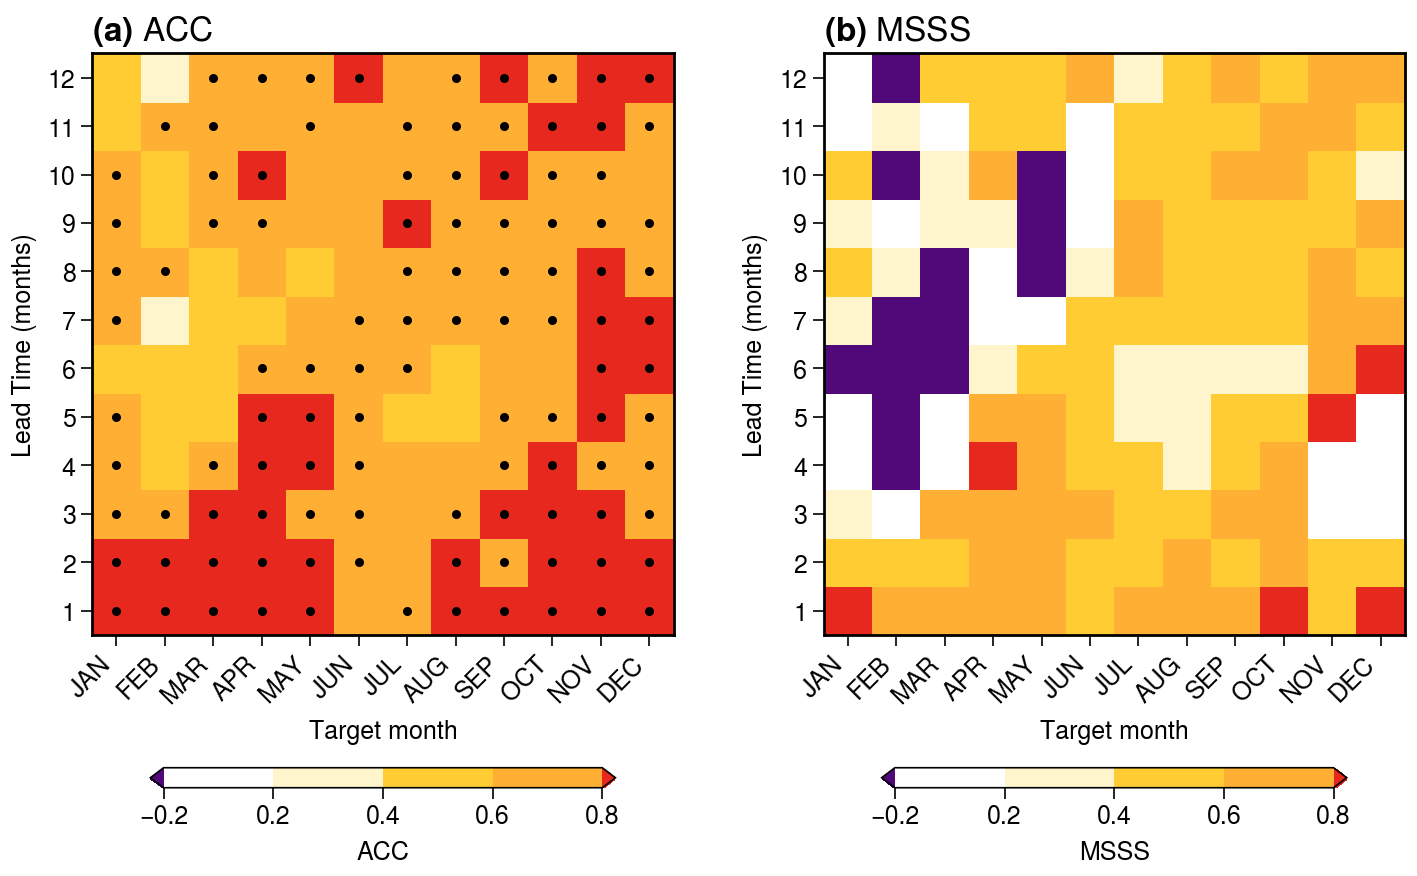

In [7]:
fig, axs = plot_target(persistence_skill, "Persistence_Skill")

eams_benchmark = persistence_benchmark.sel(region="EAMS")
print("Mean PSS:", float(eams_benchmark["TARGET_PSS"].mean(skipna=True)))
print("FDR-supported positive PSS:", int(eams_benchmark["TARGET_SIG_PSS"].sum()), "/", eams_benchmark["TARGET_SIG_PSS"].size)
print("Mean paired delta ACC:", float(eams_benchmark["TARGET_DELTA_ACC"].mean(skipna=True)))
print("FDR-supported positive delta ACC:", int(eams_benchmark["TARGET_SIG_DELTA_ACC"].sum()), "/", eams_benchmark["TARGET_SIG_DELTA_ACC"].size)

## Mode comparison

Saved: /Users/jhyun/Library/CloudStorage/OneDrive-개인/jhyun91/GloSea6-SSTA-EAMS-SEOF_G1 복사본/outputs/png/Mode_Comparison.png


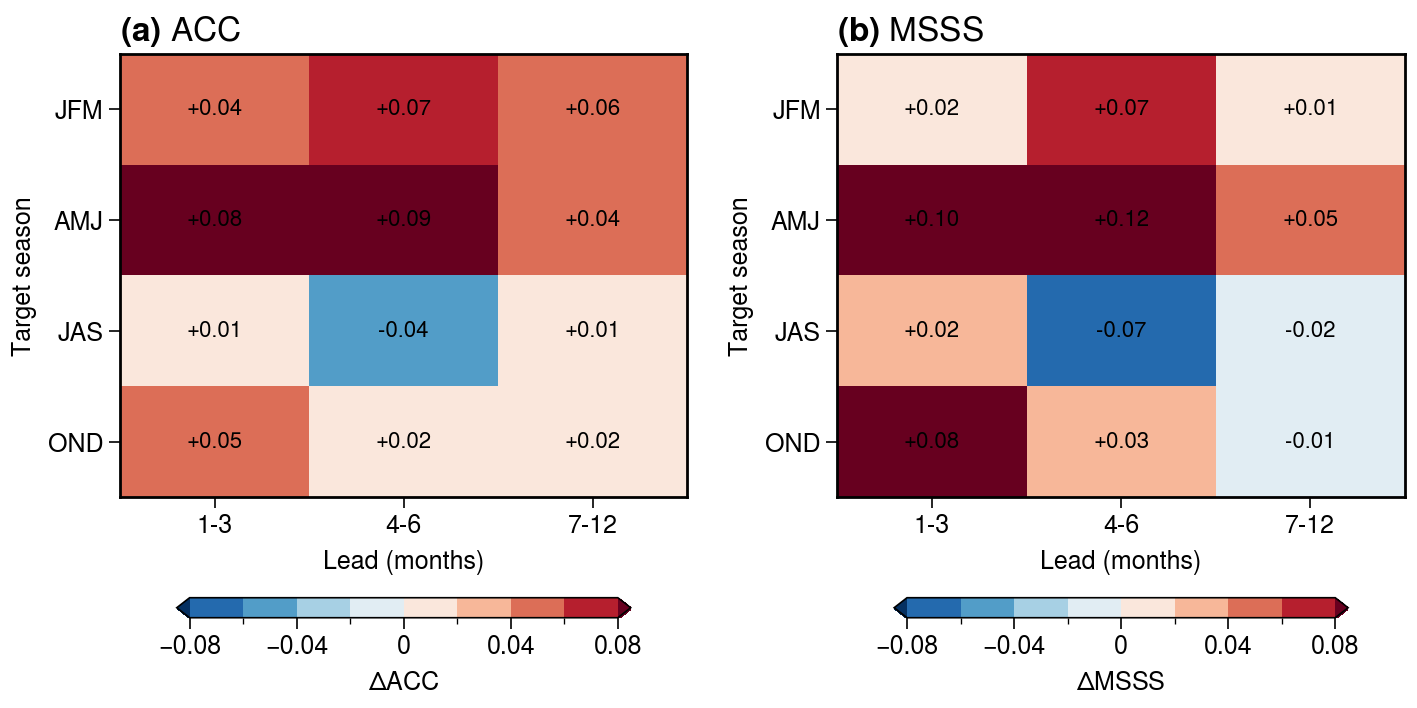

In [8]:
def mode_grid(df, column, region=None):
    x = df if region is None else df[df["region"].eq(region)]
    return np.array([
        [
            x.loc[
                x["season"].eq(season) & x["lead_group"].eq(group),
                column,
            ].iloc[0]
            for group in LEAD_GROUP_ORDER
        ]
        for season in SEASON_ORDER
    ], dtype=float)

def plot_modes(df, name):
    grids = [mode_grid(df, "DACC"), mode_grid(df, "DMSSS")]
    fig, axs = pplt.subplots(nrows=1, ncols=2, figwidth="18cm", figheight="9cm", share=False, wspace=6)
    meshes = []

    for i, (values, metric) in enumerate(zip(grids, ["ACC", "MSSS"])):
        ax = axs[i]
        clev = np.arange(-0.08, 0.10, 0.02)
        mesh = ax.pcolormesh(
            np.arange(0.5, 4.5),
            np.arange(0.5, 5.5),
            np.ma.masked_invalid(values),
            cmap="RdBu_r",
            levels=clev,
            extend="both",
            shading="flat",
        )
        meshes.append(mesh)

        for iy in range(values.shape[0]):
            for ix in range(values.shape[1]):
                if np.isfinite(values[iy, ix]):
                    ax.text(ix + 1, iy + 1, f"{values[iy, ix]:+.2f}", ha="center", va="center", fontsize=8)

        ax.format(
            title=rf"$\mathbf{{({chr(97+i)})}}$ {metric}",
            titleloc="l",
            titlesize=12,
            xticks=[1, 2, 3],
            xticklabels=LEAD_GROUP_ORDER,
            yticks=[1, 2, 3, 4],
            yticklabels=SEASON_ORDER,
            xlabel="Lead (months)",
            ylabel="Target season",
            grid=False,
            ec="black",
            lw=1.0,
        )
        ax.invert_yaxis()
        ax.xaxis.set_minor_locator(mticker.NullLocator())
        ax.yaxis.set_minor_locator(mticker.NullLocator())

    fig.colorbar(meshes[0], loc="b", cols=(1, 1), label=r"$\Delta$ACC", length=0.80, width=0.10, extend="both", extendfrac=0.03)
    fig.colorbar(meshes[1], loc="b", cols=(2, 2), label=r"$\Delta$MSSS", length=0.80, width=0.10, extend="both", extendfrac=0.03)
    savefig(fig, name)
    return fig, axs

fig, axs = plot_modes(mode_skill, "Mode_Comparison")

Saved: /Users/jhyun/Library/CloudStorage/OneDrive-개인/jhyun91/GloSea6-SSTA-EAMS-SEOF_G1 복사본/outputs/png/Regional_Mode_Comparison.png


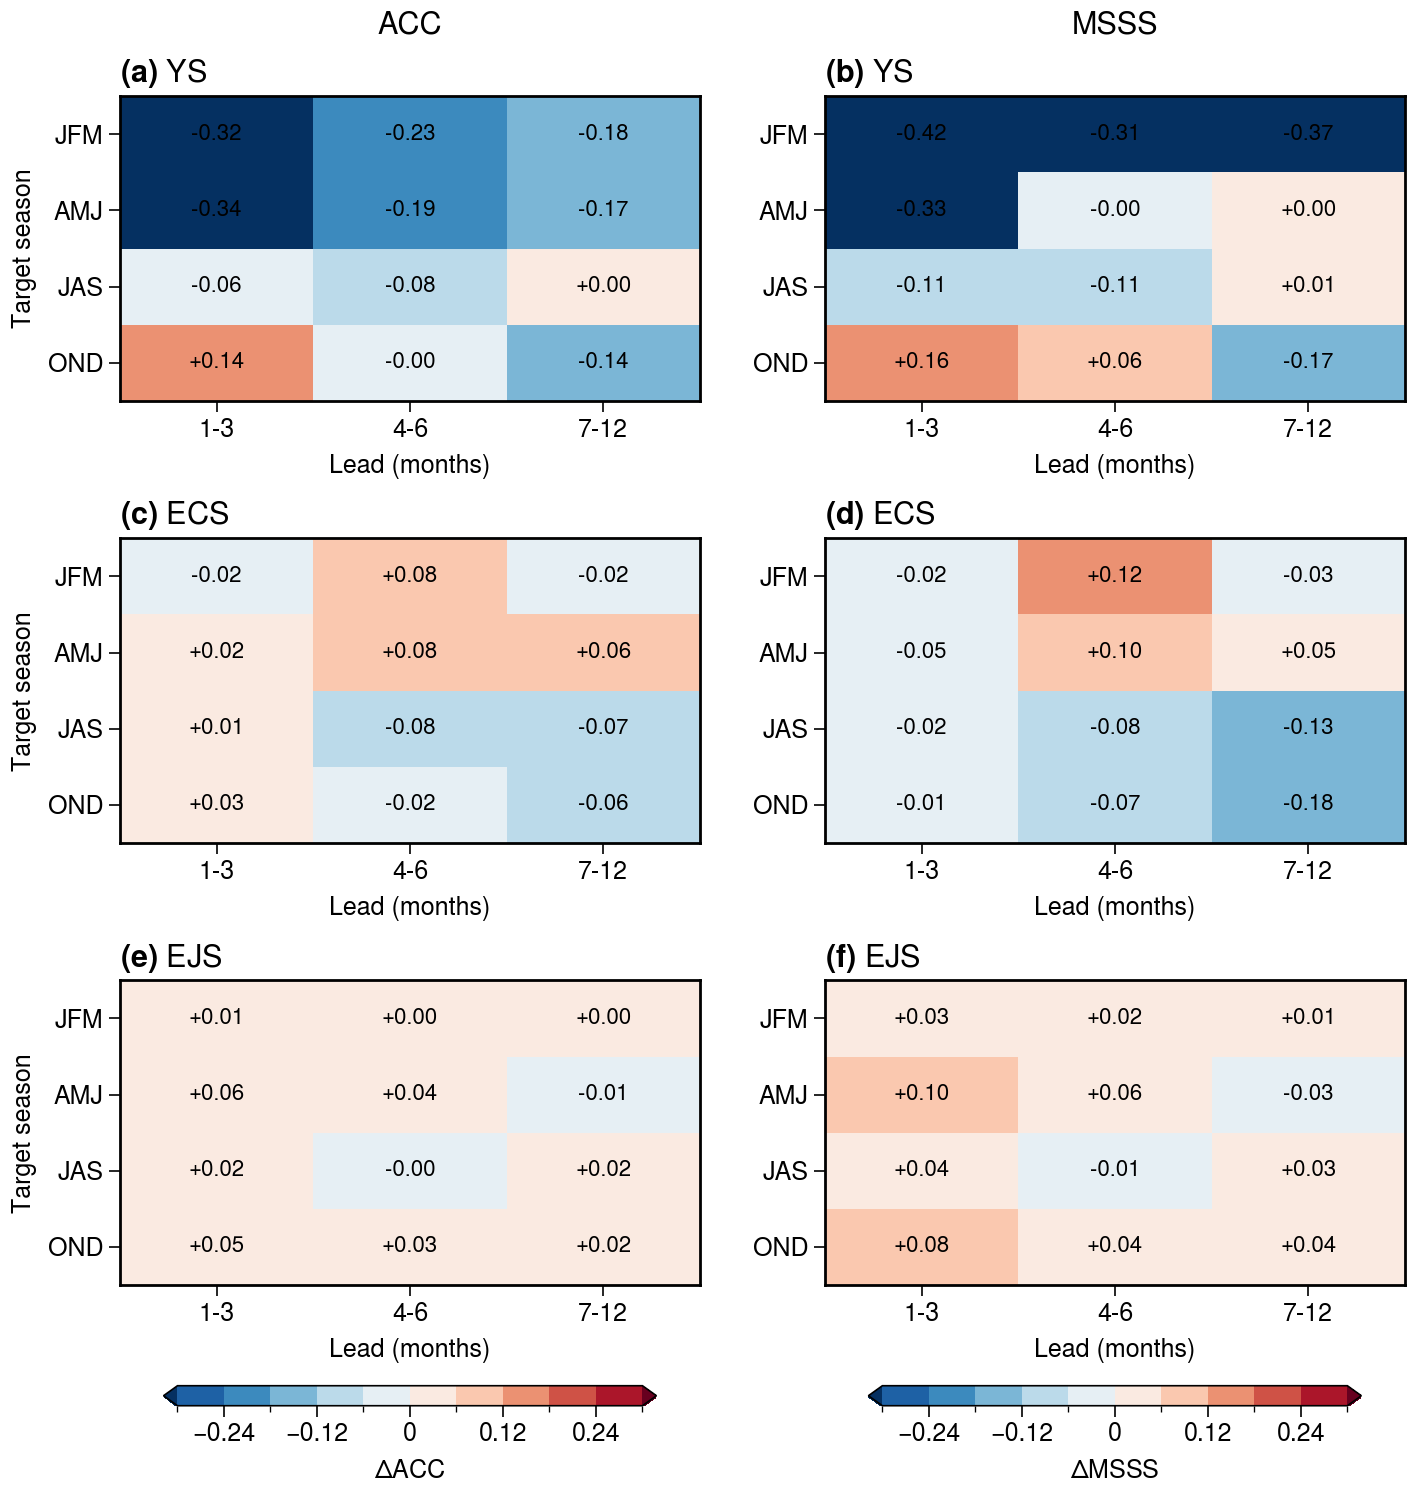

In [9]:
def plot_regional_mode_diff(df, name):
    regions = ["YS", "ECS", "EJS"]
    metrics = [("DACC", r"$\Delta$ACC"), ("DMSSS", r"$\Delta$MSSS")]
    fig, axs = pplt.subplots(nrows=3, ncols=2, figwidth="18cm", figheight="19cm", share=False, wspace=5, hspace=5.5)
    axs.format(toplabels=("ACC", "MSSS"), toplabels_kw={"fontsize": 11, "fontweight": "normal"})
    col_meshes = []

    for j, (column, cblabel) in enumerate(metrics):
        grids = [mode_grid(df, column, region) for region in regions]
        clev = np.arange(-0.30, 0.36, 0.06)
        mesh_ref = None

        for i, (region, values) in enumerate(zip(regions, grids)):
            ax = axs[i, j]
            mesh = ax.pcolormesh(
                np.arange(0.5, 4.5),
                np.arange(0.5, 5.5),
                np.ma.masked_invalid(values),
                cmap="RdBu_r",
                levels=clev,
                extend="both",
                shading="flat",
            )
            mesh_ref = mesh

            for iy in range(values.shape[0]):
                for ix in range(values.shape[1]):
                    if np.isfinite(values[iy, ix]):
                        ax.text(ix + 1, iy + 1, f"{values[iy, ix]:+.2f}", ha="center", va="center", fontsize=8)

            panel = chr(97 + i * 2 + j)
            ax.format(
                title=rf"$\mathbf{{({panel})}}$ {region}",
                titleloc="l",
                titlesize=11,
                xticks=[1, 2, 3],
                xticklabels=LEAD_GROUP_ORDER,
                yticks=[1, 2, 3, 4],
                yticklabels=SEASON_ORDER,
                xlabel="Lead (months)",
                ylabel="Target season" if j == 0 else "",
                grid=False,
                ec="black",
                lw=1.0,
            )
            ax.invert_yaxis()
            ax.xaxis.set_minor_locator(mticker.NullLocator())
            ax.yaxis.set_minor_locator(mticker.NullLocator())

        col_meshes.append((mesh_ref, cblabel))

    fig.colorbar(col_meshes[0][0], loc="b", cols=(1, 1), label=col_meshes[0][1], length=0.85, width=0.10, extend="both", extendfrac=0.03)
    fig.colorbar(col_meshes[1][0], loc="b", cols=(2, 2), label=col_meshes[1][1], length=0.85, width=0.10, extend="both", extendfrac=0.03)
    savefig(fig, name)
    return fig, axs

fig, axs = plot_regional_mode_diff(regional_mode_skill, "Regional_Mode_Comparison")